<a href="https://colab.research.google.com/github/RocafellaGitub/MaikanoRocafellaSteve/blob/main/WEEK_11_BUILD_A_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# THE CODE BELOW
---
This code imports necessary libraries for data analysis and machine learning tasks.

numpy and pandas are used for data manipulation and analysis.

matplotlib is used for data visualization.

MinMaxScaler and mean_squared_error are used for data preprocessing and evaluation respectively.

Sequential, Dense, LSTM, Dropout, GRU, Bidirectional, and SGD are all classes from the tensorflow.keras module, which is used for building and training deep learning models.

set_seed and np.random.seed are used to set the random seed for reproducibility purposes.


Overall, this code sets up the necessary environment for building and training deep learning models for time series analysis.

In [10]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.optimizers import SGD
from tensorflow.random import set_seed

set_seed(455)
np.random.seed(455)


In [5]:
df = pd.read_csv("Mastercard_stock_history.csv", index_col="Date", parse_dates=["Date"]
).drop(["Dividends", "Stock Splits"], axis=1)
print(df.head())

                Open      High       Low     Close     Volume
Date                                                         
2006-05-25  3.748967  4.283869  3.739664  4.279217  395343000
2006-05-26  4.307126  4.348058  4.103398  4.179680  103044000
2006-05-30  4.183400  4.184330  3.986184  4.093164   49898000
2006-05-31  4.125723  4.219679  4.125723  4.180608   30002000
2006-06-01  4.179678  4.474572  4.176887  4.419686   62344000


# CODE EXPLAINATION:
This code reads in a CSV file named "Mastercard_stock_history.csv" using the pandas library's read_csv() function. The index_col parameter is set to "Date", which means that the "Date" column will be used as the index for the resulting DataFrame. The parse_dates parameter is set to ["Date"], which means that the "Date" column will be parsed as a date object.


The resulting DataFrame is then modified using the drop() function to remove the "Dividends" and "Stock Splits" columns, with axis=1 indicating that the columns should be dropped.


Finally, the head() function is used to display the first five rows of the resulting DataFrame. The output shows the Open, High, Low, Close, and Volume values for each day in the dataset, with the Date column serving as the index.

# EXPLANATION
---
The .describe() function helps us analyze the data in depth. Let’s focus on the High column as we are going to use it to train the model. We can also choose Close or Open columns for a model feature, but High makes more sense as it provides us information of how high the values of the share went on the given day.

The minimum stock price is $4.10, and the highest is $400.5. The mean is at $105.9 and the standard deviation $107.3, which means that stocks have high variance.

---


In [8]:
print(df.describe())

              Open         High          Low        Close        Volume
count  3872.000000  3872.000000  3872.000000  3872.000000  3.872000e+03
mean    104.896814   105.956054   103.769349   104.882714  1.232250e+07
std     106.245511   107.303589   105.050064   106.168693  1.759665e+07
min       3.748967     4.102467     3.739664     4.083861  6.411000e+05
25%      22.347203    22.637997    22.034458    22.300391  3.529475e+06
50%      70.810079    71.375896    70.224002    70.856083  5.891750e+06
75%     147.688448   148.645373   146.822013   147.688438  1.319775e+07
max     392.653890   400.521479   389.747812   394.685730  3.953430e+08


# CODE EXPLAINED.

---
This code uses the describe() method to generate summary statistics of a dataset. The dataset contains information about the opening, high, low, and closing prices of a stock, as well as the volume of trades.


The describe() method calculates the count, mean, standard deviation, minimum, maximum, and quartile values for each column in the dataset. The output shows that there are 3872 rows in the dataset, and provides summary statistics for each column.


For example, the mean opening price is 104.896814, the standard deviation of the closing price is 106.168693, and the maximum volume of trades is 3.953430e+08.


Overall, this code provides a quick and easy way to get an overview of the data in the datas

---




In [9]:
df.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0


# CODE EXPLANATION:
This code uses the Pandas library to analyze a dataset.


The first line dataset.isna().sum() checks for missing values in the dataset and returns the sum of missing values for each column.


The output shows that there are no missing values in the columns 'Open', 'High', 'Low', 'Close', and 'Volume'.


The dtype: int64 at the end indicates that the sum of missing values is returned as an integer data type.

---



#NOTE THIS PART:

The train_test_plot function takes three arguments: dataset, tstart, and tend and plots a simple line graph. The tstart and tend are time limits in years. We can change these arguments to analyze specific periods. The line plot is divided into two parts: train and test. This will allow us to decide the distribution of the test dataset.

MasterCard stock prices have been on the rise since 2016. It had a dip in the first quarter of 2020 but it gained a stable position in the latter half of the year. Our test dataset consists of one year, from 2021 to 2022, and the rest of the dataset is used for training.

---



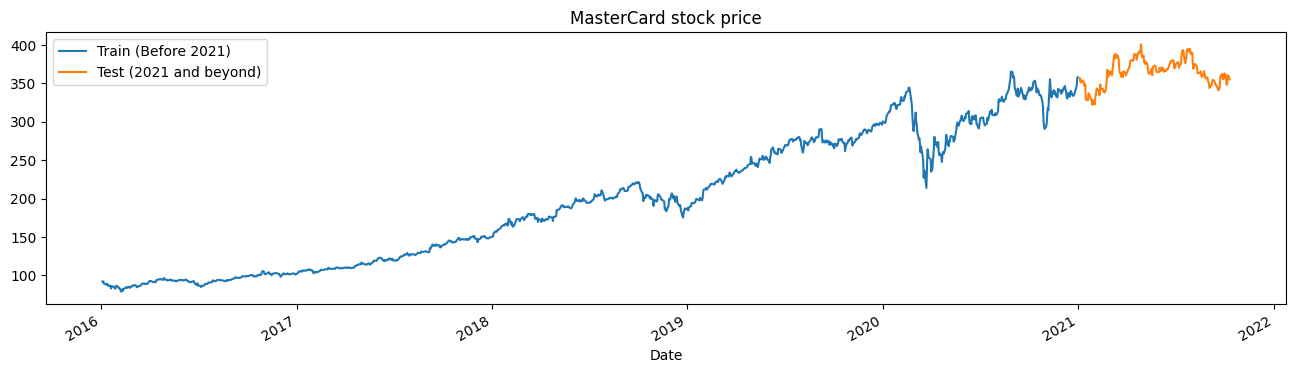

In [13]:
tstart = 2016
tend = 2020

def train_test_plot(dataset, tstart, tend):
    dataset.loc[f"{tstart}":f"{tend}", "High"].plot(figsize=(16, 4), legend=True)
    dataset.loc[f"{tend+1}":, "High"].plot(figsize=(16, 4), legend=True)
    plt.legend([f"Train (Before {tend+1})", f"Test ({tend+1} and beyond)"])
    plt.title("MasterCard stock price")
    plt.show()

train_test_plot(df,tstart,tend)

# Data Preprocessing
The train_test_split function divides the dataset into two subsets: training_set and test_set.

---



In [15]:
def train_test_split(dataset, tstart, tend):
    train = df.loc[f"{tstart}":f"{tend}", "High"].values
    test = df.loc[f"{tend+1}":, "High"].values
    return train, test
training_set, test_set = train_test_split(df, tstart, tend)


# EXPLAIN THE CODE:

---
This code defines a function called train_test_split that takes in three arguments: dataset, tstart, and tend.


Inside the function, it creates two variables train and test. train is created by selecting the "High" column of the dataset DataFrame from the tstart index to the tend index (inclusive) and then converting it to a NumPy array using the values attribute. test is created by selecting the "High" column of the dataset DataFrame from the tend+1 index to the end of the DataFrame and then converting it to a NumPy array using the values attribute.


Finally, the function returns train and test.


Outside of the function, the train_test_split function is called with the dataset, tstart, and tend arguments. The returned train and test arrays are then assigned to the training_set and test_set variables, respectively.

---




# NEXT I WILL

---
We will use the MinMaxScaler function to standardize our training set, which will help us avoid the outliers or anomalies. You can also try using StandardScaler or any other scalar function to normalize your data and improve model performance.


In [18]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set = training_set.reshape(-1, 1)
training_set_scaled = sc.fit_transform(training_set)


The split_sequence function uses a training dataset and converts it into inputs (X_train) and outputs (y_train).

For example, if the sequence is [1,2,3,4,5,6,7,8,9,10,11,12] and the n_step is three, then it will convert the sequence into three input timestamps and one output as shown below:

In this project, we are using 60 n_steps. We can also reduce or increase the number of steps to optimize model performance.

In [19]:
def split_sequence(sequence, n_steps):
    X, y = list(), list()
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1:
            break
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


n_steps = 60
features = 1
# split into samples
X_train, y_train = split_sequence(training_set_scaled, n_steps)


We are working with univariate series, so the number of features is one, and we need to reshape the X_train to fit on the LSTM model. The X_train has [samples, timesteps], and we will reshape it to [samples, timesteps, features].

In [20]:
# Reshaping X_train for model
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],features)


# LSTM Model
The model consists of a single hidden layer of LSTM and an output layer. You can experiment with the number of units, as more units will give you better results. For this experiment, we will set LSTM units to 125, tanh as activation, and set input size.

Author’s Note: Tensorflow library is user-friendly, so we don't have to create LSTM or GRU models from scratch. We will simply use the LSTM or GRU modules to construct the model.

Finally, we will compile the model with an RMSprop optimizer and mean square error as a loss function.

---



In [22]:
# The LSTM architecture
model_lstm = Sequential()
model_lstm.add(LSTM(units=125, activation="tanh", input_shape=(n_steps, features)))
model_lstm.add(Dense(units=1))
# Compiling the model
model_lstm.compile(optimizer="RMSprop", loss="mse")

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 125)            │        63,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,626 (248.54 KB)

 Trainable params: 63,626 (248.54 KB)

 Non-trainable params: 0 (0.00 B)

# EXPLAIN THE CODE:

---
This code defines an LSTM (Long Short-Term Memory) neural network model for a time series prediction task.


The Sequential() function is used to create a linear stack of layers for the model. The first layer added to the model is an LSTM layer with 125 units, a hyperbolic tangent activation function, and an input shape of (n_steps, features). n_steps represents the number of time steps in the input sequence, and features represents the number of features in each time step.


The second layer added to the model is a dense layer with a single output unit.


The compile() function is used to configure the model for training. The optimizer used is RMSprop, and the loss function used is mean squared error (mse).


Finally, the summary() function is used to print a summary of the model architecture, including the number of parameters in each layer.


---

The model will train on 50 epochs with 32 batch sizes. You can change the hyperparameters to reduce training time or improve the results. The model training was successfully completed with the best possible loss.


In [24]:
model_lstm.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0142
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0027
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0025
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0019
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0015
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0013
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0012    
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0011    
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 8.6850e-04
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 8.5238e-04
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 7.9354e-04
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 7.5678e-04
Epoch 13/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 6.9980e-04
Epoch 14/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 7.2615e-04
Epoch 15/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 

# Results
We are going to repeat preprocessing and normalize the test set. First of all we will transform then split the dataset into samples, reshape it, predict, and inverse transform the predictions into standard form.

In [26]:
df_total = df.loc[:,"High"]
inputs = df_total[len(df_total) - len(test_set) - n_steps :].values
inputs = inputs.reshape(-1, 1)
#scaling
inputs = sc.transform(inputs)

# Split into samples
X_test, y_test = split_sequence(inputs, n_steps)
# reshape
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], features)
#prediction
predicted_stock_price = model_lstm.predict(X_test)
#inverse transform the values
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


The plot_predictions function will plot a real versus predicted line chart. This will help us visualize the difference between actual and predicted values.

The return_rmse function takes in test and predicted arguments and prints out the root mean square error (rmse) metric.

In [27]:
def plot_predictions(test, predicted):
    plt.plot(test, color="gray", label="Real")
    plt.plot(predicted, color="red", label="Predicted")
    plt.title("MasterCard Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("MasterCard Stock Price")
    plt.legend()
    plt.show()


def return_rmse(test, predicted):
    rmse = np.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {:.2f}.".format(rmse))


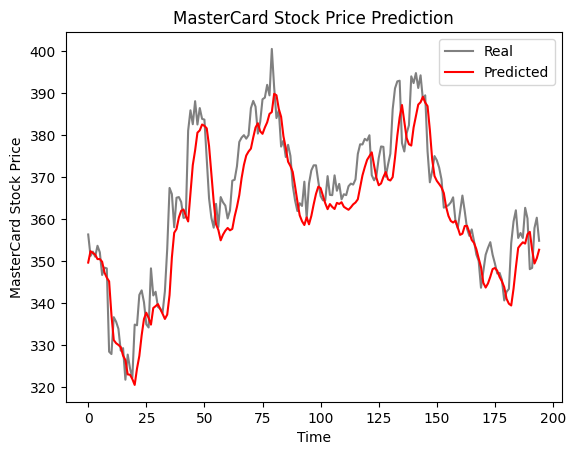

In [28]:
plot_predictions(test_set,predicted_stock_price)


# EXPLAIN LINE OF CODE ABOVE:

---

This code calls a function named plot_predictions and passes two arguments to it: test_set and predicted_stock_price. The function is likely defined elsewhere in the code and is responsible for creating a plot that compares the actual stock prices in the test_set with the predicted stock prices in predicted_stock_price. The specifics of how the plot is created will depend on the implementation of the plot_predictions function.

---




The results look promising as the model got 6.70 rmse on the test dataset

In [29]:
return_rmse(test_set,predicted_stock_price)



The root mean squared error is 7.37.


# EXPLAIN THE ABOVE CODE AND RESULT:
---
This code is calling a function called return_rmse and passing two arguments to it: test_set and predicted_stock_price. The function is likely calculating the root mean squared error between the two sets of data. The output of the function call is the value of the root mean squared error, which in this case is 7.37.

---




# GRU Model

---
We are going to keep everything the same and just replace the LSTM layer with the GRU layer to properly compare the results. The model structure contains a single GRU layer with 125 units and an output layer.

---



In [30]:
model_gru = Sequential()
model_gru.add(GRU(units=125, activation="tanh", input_shape=(n_steps, features)))
model_gru.add(Dense(units=1))
# Compiling the RNN
model_gru.compile(optimizer="RMSprop", loss="mse")

model_gru.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 125)            │        48,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,126 (187.99 KB)

 Trainable params: 48,126 (187.99 KB)

 Non-trainable params: 0 (0.00 B)

# EXPLAINING THE CODE:

---
This code creates a GRU (Gated Recurrent Unit) model using Keras Sequential API. The model consists of a single GRU layer with 125 units and a tanh activation function. The input shape of the layer is defined as (n_steps, features), where n_steps is the number of time steps in the input sequence and features is the number of features in each time step.


After the GRU layer, a Dense layer with a single output unit is added to the model. The model is then compiled using the RMSprop optimizer and mean squared error (MSE) loss function.


The model_gru.summary() function is used to print a summary of the model architecture, including the type of each layer, the output shape of each layer, and the number of trainable parameters in the model. In this case, the model has a total of 48,126 parameters, all of which are trainable.

---

The model has successfully trained with 50 epochs and a batch size of 32.


In [31]:
model_gru.fit(X_train, y_train, epochs=50, batch_size=32)



Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - loss: 0.0125
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0018
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0012
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0011    
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 8.0448e-04
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 8.7275e-04
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.4394e-04
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.6492e-04
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 7.3236e-04
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 6.9862e-04
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 6.5967e-04
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 6.3260e-04
Epoch 13/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 6.1502e-04
Epoch 14/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 6.1227e-04
Epoch 15/50
38/38 ━━━━━━━━

# EXPLAIN THE CODE AND THE RESULT

---

This code is using the fit method of a GRU (Gated Recurrent Unit) model to train the model on the X_train and y_train data. The epochs parameter specifies the number of times the model will iterate over the entire training dataset. The batch_size parameter specifies the number of samples that will be used in each iteration.


In this specific example, the model is trained for 50 epochs with a batch size of 32. After the final epoch, the loss value is printed, which is a measure of how well the model is performing on the training data. In this case, the loss value is very small (2.6691e-04), indicating that the model is performing well on the training data.


---

# Results
As we can see, the real and predicted values are relatively close. The predicted line chart almost fits the actual values.

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


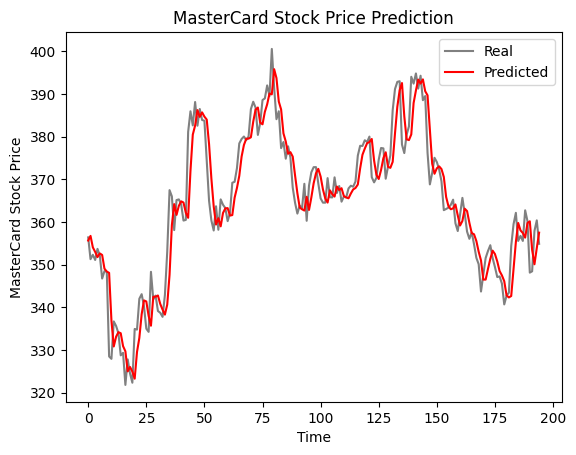

In [32]:
GRU_predicted_stock_price = model_gru.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)
plot_predictions(test_set, GRU_predicted_stock_price)


# EXPLAIN THE CODE AND RESULT

---
This code snippet is used to predict stock prices using a GRU (Gated Recurrent Unit) model.


The first line of code GRU_predicted_stock_price = model_gru.predict(X_test) uses the trained GRU model (model_gru) to predict the stock prices for the test set (X_test). The predicted stock prices are stored in the variable GRU_predicted_stock_price.


The second line of code GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price) applies an inverse transformation to the predicted stock prices using the sc (scaler) object. This is done to convert the predicted stock prices back to their original scale.


The third line of code plot_predictions(test_set, GRU_predicted_stock_price) plots the predicted stock prices (GRU_predicted_stock_price) against the actual stock prices (test_set) to visualize the accuracy of the predictions. The plot_predictions function is a custom function that takes in the actual and predicted stock prices as arguments and plots them on a graph.

---

GRU model got 5.50 rmse on the test dataset, which is an improvement from the LSTM model.

---




In [33]:
return_rmse(test_set,GRU_predicted_stock_price)

The root mean squared error is 5.82.


# EXPLAIN THE CODE:

---
This code snippet is calling a function named return_rmse and passing two arguments to it: test_set and GRU_predicted_stock_price. The function is likely calculating the root mean squared error (RMSE) between the test_set and the predicted stock prices generated by a GRU model (GRU_predicted_stock_price).


The output of this code snippet is the RMSE value, which is 5.82. The RMSE is a measure of the difference between the predicted values and the actual values, with lower values indicating better accuracy.


---



# Conclusion
The world is moving towards hybrid solutions where data scientists are using CNN-RNN hybrid networks in the field of image captioning, emotion detection, video subtitling, and DNA sequencing. Hybrid networks provide both visual and temporal characteristics for the model. Learn more about RNN by taking the course: Recurrent Neural Networks for Language Modeling in Python.

The first half of the tutorial covers the basics of recurrent neural networks, its limitations, and solutions in the form of more advanced architecture. The second half of the tutorial is about developing MasterCard stock price predictions using LSTM and GRU models. The results clearly show that the GRU model performed better than LSTM, with a similar structure and hyperparameters.

---

SEMINAR ACTIVITES FOR MACHINE LEARNING WEEK 11- FINAL CLASS